# Eval 

## Libs and paths

In [1]:
import pandas as pd
import numpy as np
import json
import os
import datetime as dt
import pickle
from unidecode import unidecode
import matplotlib.pyplot as plt
import time
import warnings

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.manifold import MDS

warnings.filterwarnings('ignore')

src_path = os.path.abspath(os.getcwd())
root_path = os.path.dirname(src_path)

In [2]:
data_path = os.path.join(root_path, 'data')
raw_path = os.path.join(data_path, 'raw')
interim_path = os.path.join(data_path, 'interim')
processed_path = os.path.join(data_path, 'processed')
plots_path = os.path.join(processed_path, 'plots')
models_path = os.path.join(root_path, 'models')
config_path = os.path.join(root_path, 'config')

## Ideology

In [19]:
df_bloco = pd.read_csv(os.path.join(interim_path,'blocos_partidarios.csv'),sep =';')
df_bloco.loc[df_bloco['siglaPartido'] == 'PMDB','siglaPartido'] = 'MDB'

In [43]:
cols = ['idDeputado', 'nome', 'idPartido', 'siglaPartido', 'data', 'idLegislatura','idProposicao', 'idVotacao','voto']
df_votos = pd.read_csv(os.path.join(interim_path, 'features.csv'), sep = ';', usecols=cols).drop_duplicates()
df_votos['year'] = pd.to_datetime(df_votos['data']).dt.year
df_votos.loc[df_votos['siglaPartido'] == 'PMDB','siglaPartido'] = 'MDB'

In [61]:
# df_votos.idLegislatura.value_counts().reset_index().sort_values('index')

# for c in ['idProposicao', 'idVotacao','idDeputado']:
#     print(c)
#     a=df_votos[['idLegislatura', c]].drop_duplicates().idLegislatura.value_counts().reset_index().sort_values('index')
#     display(a[1:].sum())

### Legislature

In [31]:
pct_votes = .6
pct_dep = .6

In [32]:
n_rows = 2
n_cols = 3
size = 5

In [33]:
coord_list = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1,2), (2,0)]

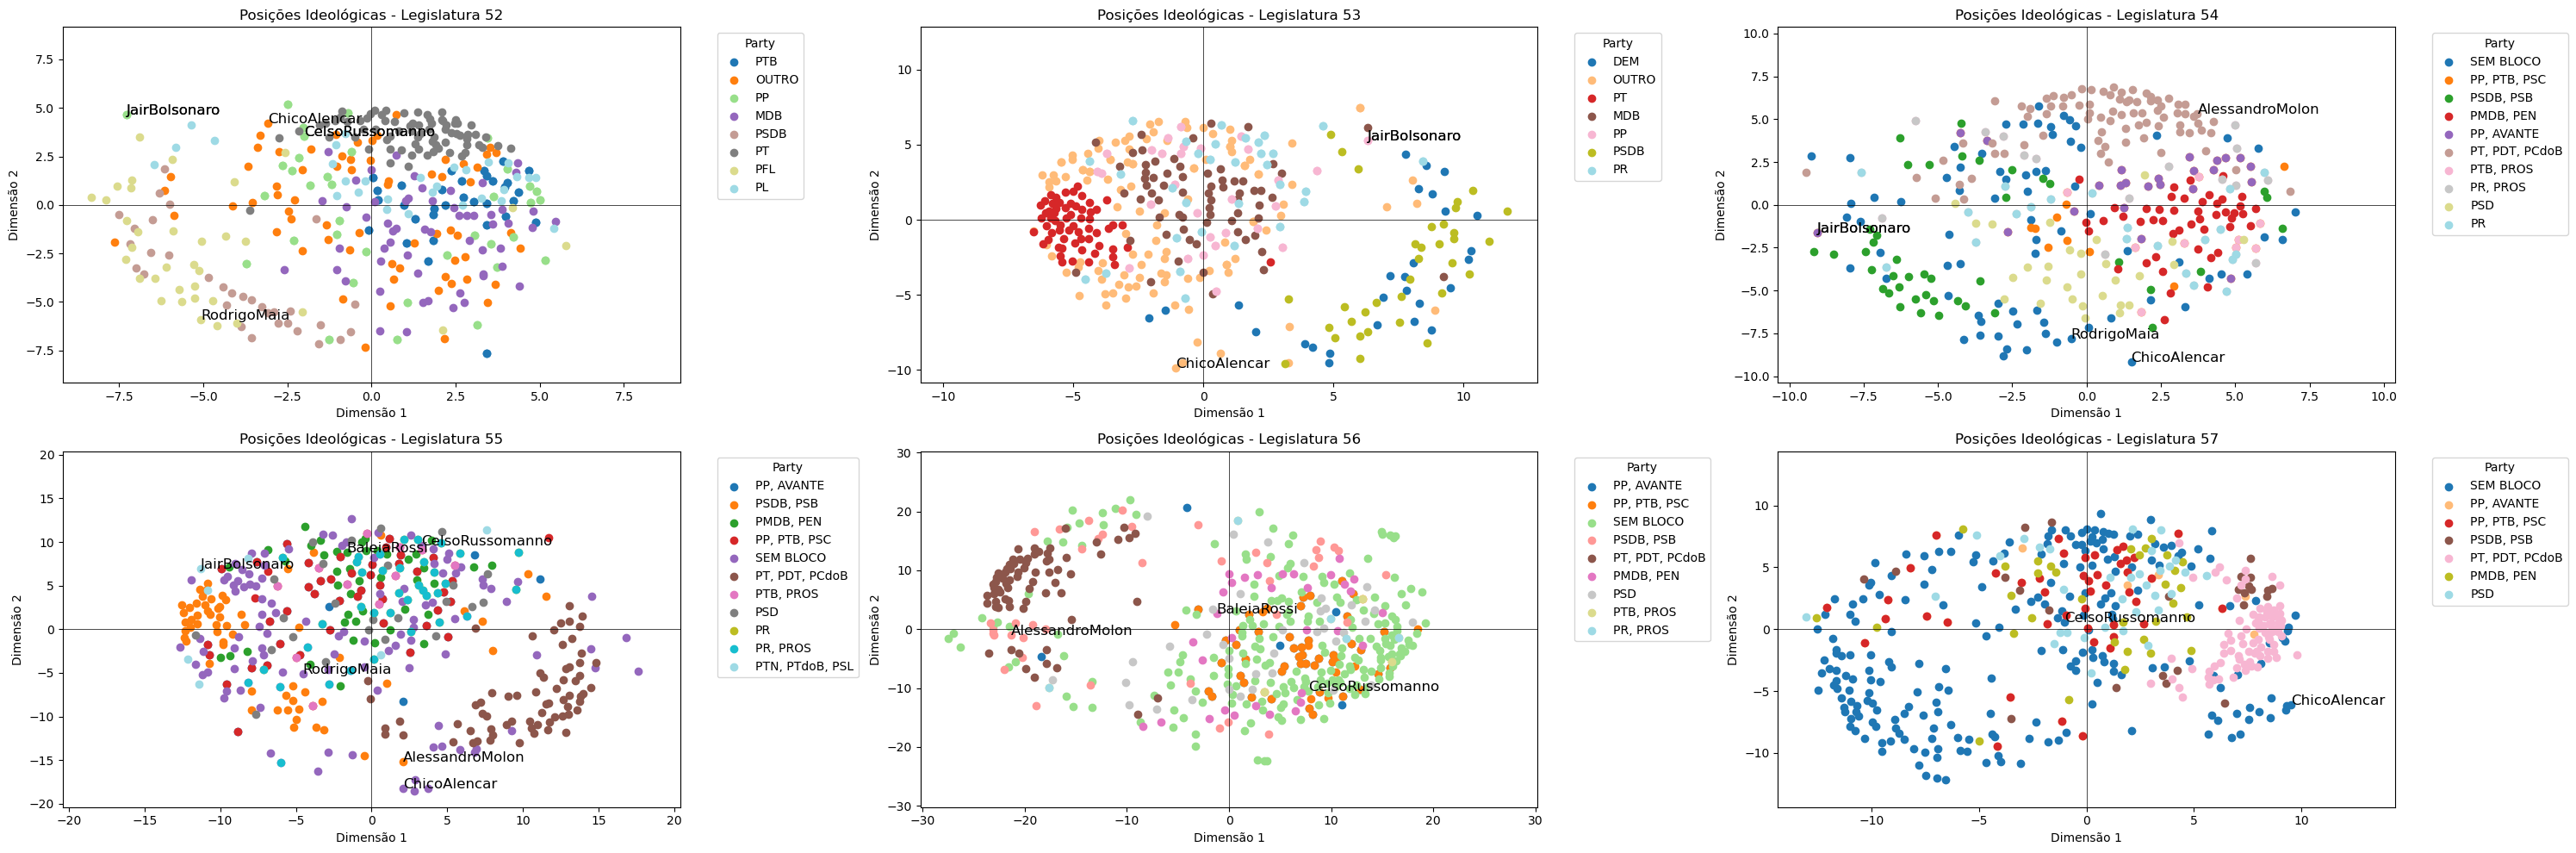

In [34]:
legis_list = sorted(df_votos['idLegislatura'].unique())[1:]
fig, axs = plt.subplots(n_rows, n_cols, figsize=(2 * size * n_cols, size * n_rows))
for i,legis in enumerate(legis_list):
    
    #filter votes data
    df_votos_f = df_votos[df_votos['idLegislatura'] == legis]    
    df_party  = df_votos_f.sort_values(['idDeputado','data'])[['nome', 'siglaPartido']].drop_duplicates().groupby('nome', as_index=False).last()
    df_votos_f = df_votos_f.drop('siglaPartido',axis=1).merge(df_party,how='left', on = 'nome')
    
    #remove votes with low voters
    df_vot_size = df_votos_f['idVotacao'].value_counts().reset_index()
    df_vot_size.columns = ['idVotacao', 'size']
    df_vot_size['pct'] = df_vot_size['size']/513
    list_vote_id = df_vot_size[df_vot_size['pct']>pct_votes]['idVotacao']
    
    #remove deputies with low vote frequency
    df_dep_size = df_votos_f[df_votos_f['idVotacao'].isin(list_vote_id)][['idDeputado','nome']].value_counts().reset_index().rename(columns = {0:'size'})
    df_dep_size['pct'] = df_dep_size['size']/len(list_vote_id)
    list_dep_id = df_dep_size[df_dep_size['pct']>pct_dep]['idDeputado']
        
    df_votos_f = df_votos_f[(df_votos_f['idVotacao'].isin(list_vote_id)) & (df_votos_f['idDeputado'].isin(list_dep_id))]
    
    #map votes 
    mapping_votes = {'Não': 0, 'Sim': 1, 'Artigo 17': np.nan, 'Abstenção': np.nan , 'Obstrução': -.5}
    df_votos_f['vote'] = df_votos_f['voto'].replace(mapping_votes)

    id_cols = ['idDeputado', 'nome', 'siglaPartido']
    df = df_votos_f.pivot(index=id_cols, columns='idVotacao', values='vote').fillna(.5)
    
    # apply MDS model
    mds1 = MDS(n_components=1, dissimilarity='euclidean', random_state=42)
    positions1 = mds1.fit_transform(df.to_numpy())
    positions1_df = pd.DataFrame(positions1, columns=['ideologia'],index=df.index).reset_index().sort_values('ideologia')

    mds = MDS(n_components=2, dissimilarity='euclidean', random_state=42)
    positions = mds.fit_transform(df.to_numpy())
    
    # create dataframe with calculated positions
    df_bloco_f = df_bloco[df_bloco['idLegislatura'] == 55].drop('idLegislatura',axis=1)
    positions_df = pd.DataFrame(positions, columns=['dim1', 'dim2'],index=df.index).reset_index()
        
    #filter party to show with more than 20 deputies 
    party_size = positions_df[['siglaPartido']].value_counts().to_frame().reset_index().rename(columns = {0:'size'})
    party_size['party']=party_size[['siglaPartido']]
    party_size.loc[party_size['size']<20,'party'] = 'OUTRO'
    
    positions_df=positions_df.merge(party_size, how='left', on = 'siglaPartido')
    positions_df=positions_df.merge(df_bloco_f, how='left', on = 'siglaPartido')
    positions_df['nome_'] = positions_df['nome_'].fillna('SEM BLOCO')
    
    #choose the cluster: before 54 cluster by name - after by party
    flag_party = False if legis >= 54 else True
    col = 'party' if flag_party else 'nome_'
    
    #define colors for party
    items = positions_df[col].unique()
    cmap = plt.get_cmap('tab20')  # Escolhendo uma colormap com cores distintas
    colors = cmap(np.linspace(0, 1, len(items)))
    dict_colors = {item: color for item, color in zip(items, colors)}

    #choose deputies to print
    print_names = True
    names = ['Alessandro Molon', 'Baleia Rossi', 'Celso Russomanno', 'Chico Alencar',  'Jair Bolsonaro', 'Rodrigo Maia']
    # names = ['Glauber Braga', 'Ivan Valente', 'Chico Alencar', 'Weliton Prado', 'Luiza Erundina', 'Edmilson Rodrigues']
    
    coord = coord_list[i]
    
    for item, color in dict_colors.items():
        party_members = positions_df[positions_df[col] == item]
        axs[coord].scatter(party_members['dim1'], party_members['dim2'], color=color, label=item)
    
    min_value = min(positions_df[['dim1', 'dim2']].min())
    max_value = max(positions_df[['dim1', 'dim2']].abs().max())
    
    if print_names:
        for i, row in positions_df.iterrows():
            if row['nome'] in names:
                axs[coord].text(row['dim1'], row['dim2'], row['nome'].replace(' ', ''), fontsize=12,)    
    
    axs[coord].axhline(0, color='black', linewidth=0.5)
    axs[coord].axvline(0, color='black', linewidth=0.5)
    
    axs[coord].set_xlim(min_value*1.1, max_value*1.1)
    axs[coord].set_ylim(min_value*1.1, max_value*1.1)
    
    axs[coord].legend(title='Party', bbox_to_anchor=(1.05, 1), loc='upper left')
    axs[coord].set_title(f'Posições Ideológicas - Legislatura {int(legis)}')
    axs[coord].set_xlabel('Dimensão 1')
    axs[coord].set_ylabel('Dimensão 2')
    # plt.grid(True)

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, f'ideology.png'),dpi=500)
plt.show()

### Year

In [36]:
n_rows = 4
n_cols = 3
size = 5

In [37]:
coord_list = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1,2), (2,0), (2,1), (2,2),(3,0), (3,1)]

In [38]:
pct_votes = .4
pct_dep = .6

2014 0.39
2015 0.15
2016 0.31
2017 0.28
2018 0.4
2019 0.21
2020 0.16
2021 0.16
2022 0.28
2023 0.17
2024 0.23


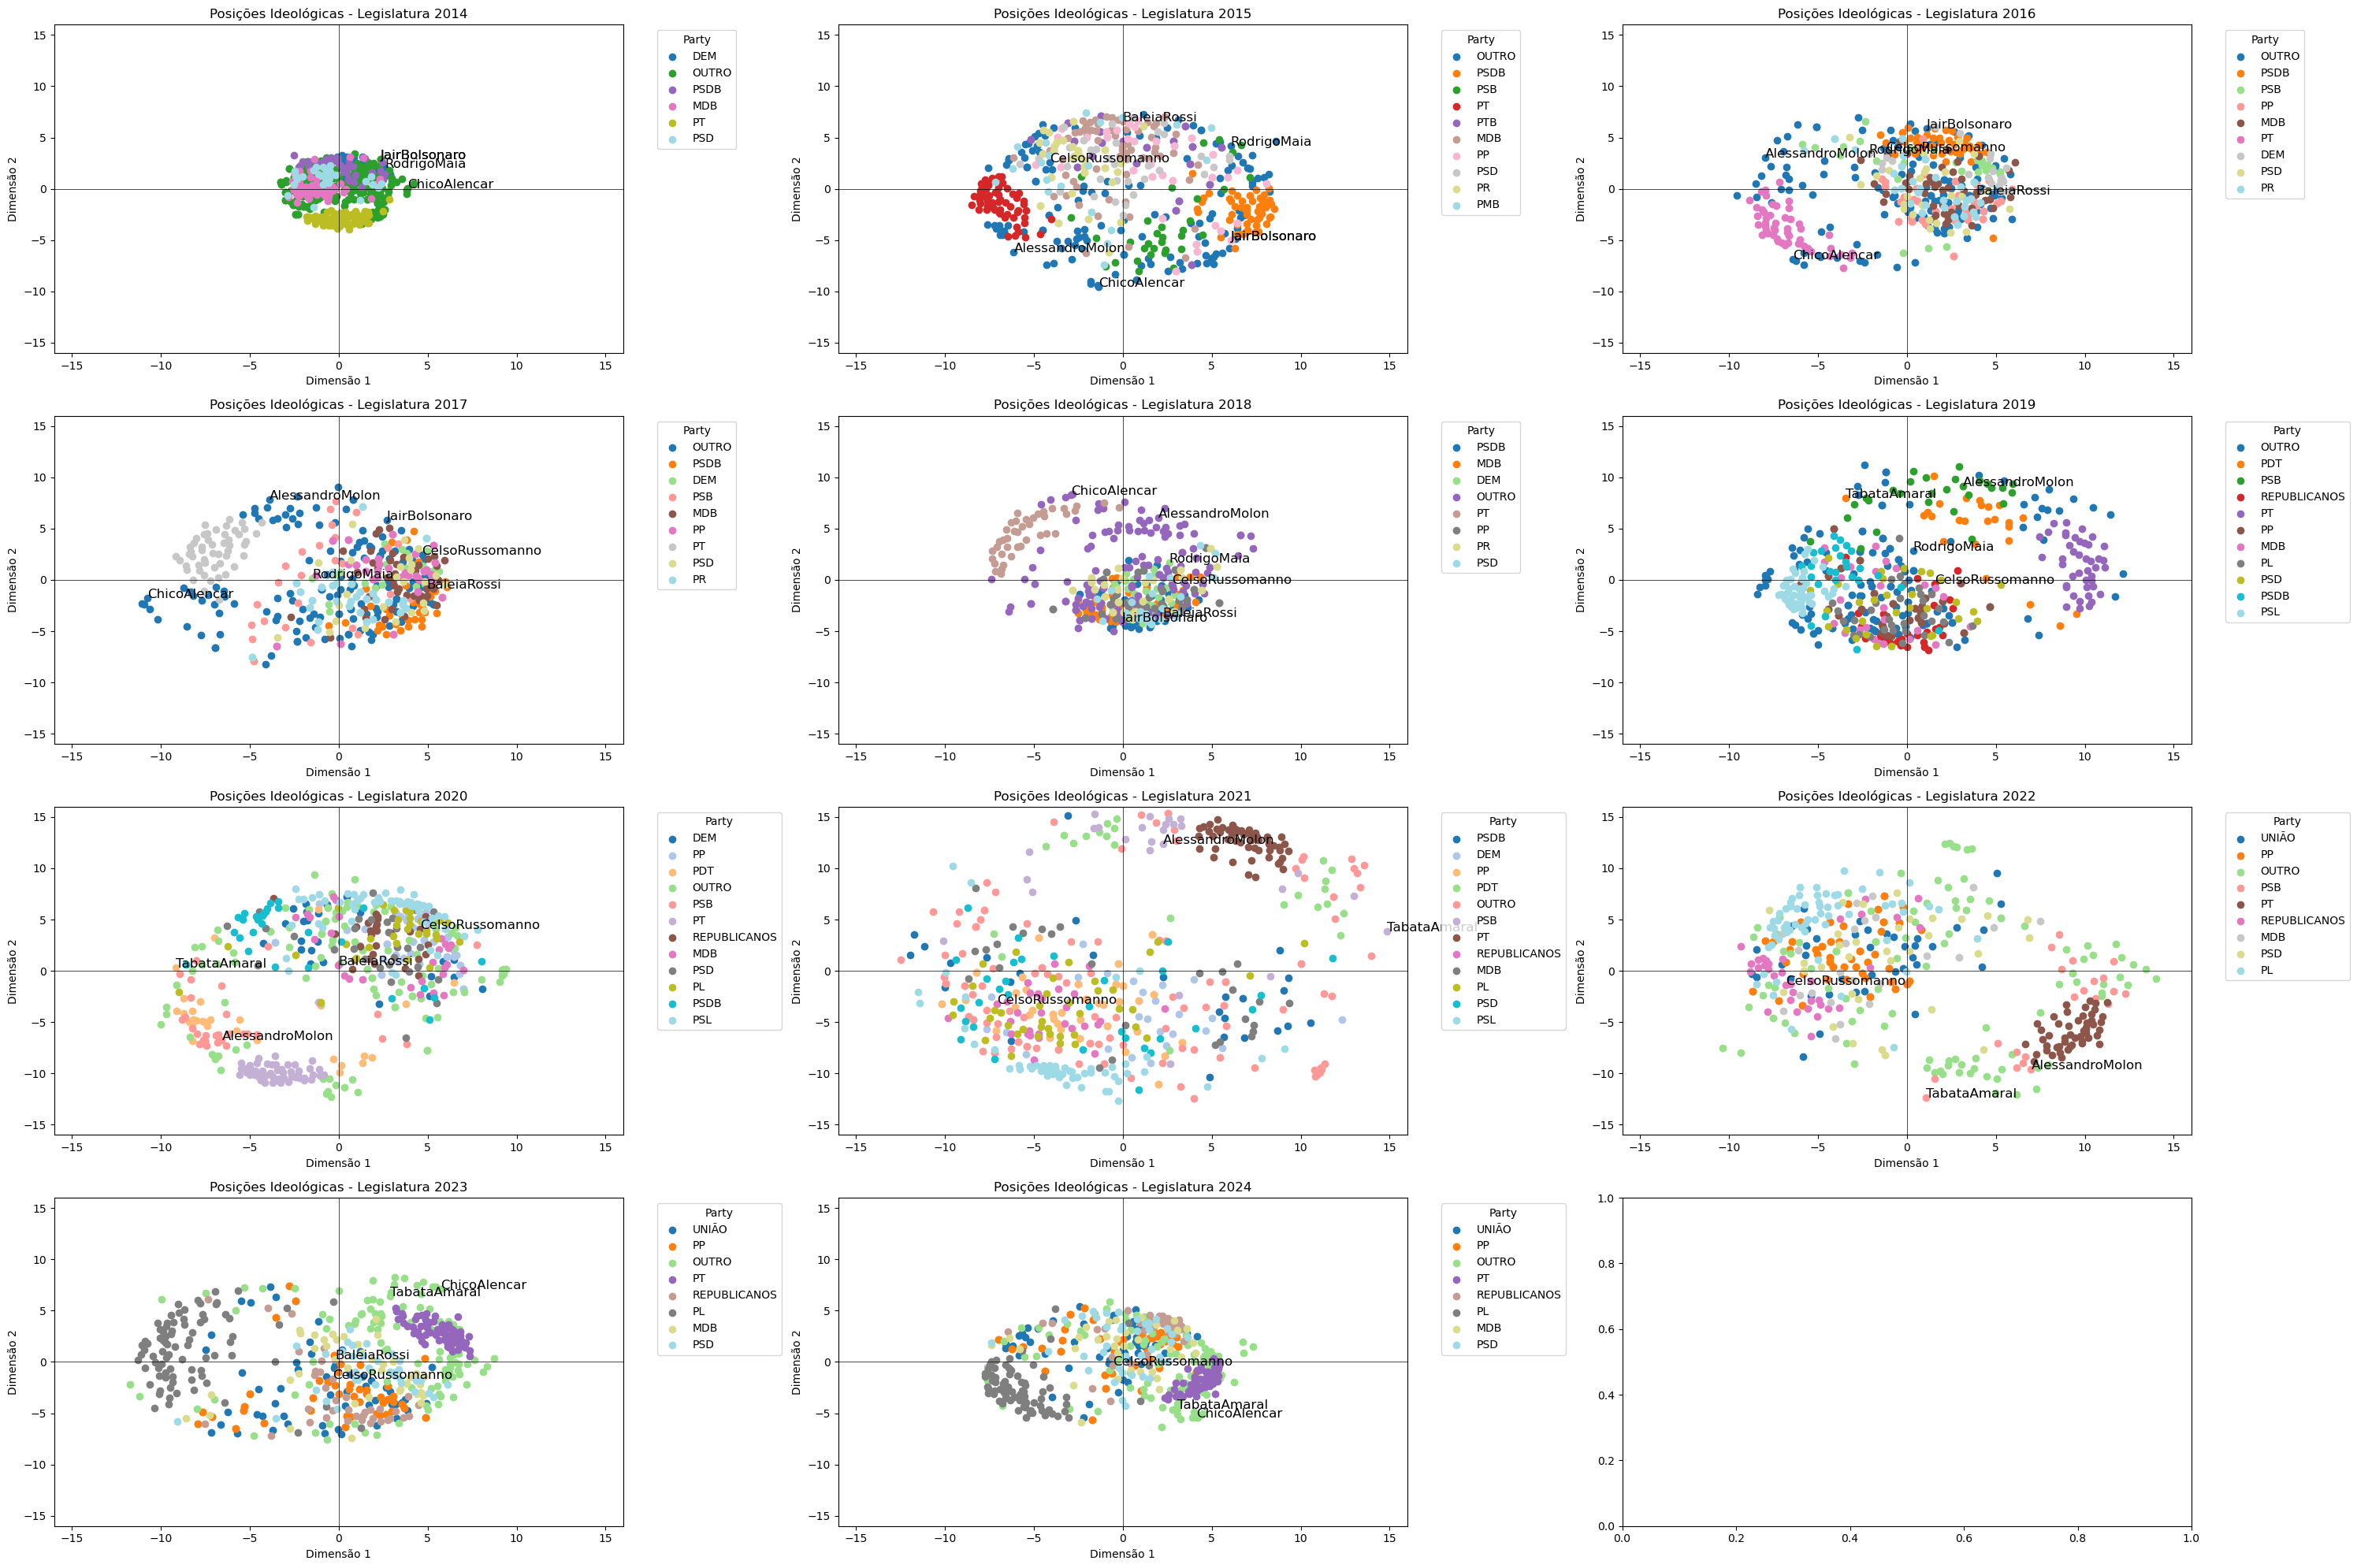

In [39]:
sorted(df_votos['year'].unique())

fig, axs = plt.subplots(n_rows, n_cols, figsize=(2 * size * n_cols, size * n_rows))
year_list =  [2014,2015,2016,2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
for i,year in enumerate(year_list):
    
    #filter votes data
    df_votos_f = df_votos[df_votos['year'] == year]    
    df_party  = df_votos_f.sort_values(['idDeputado','data'])[['nome', 'siglaPartido']].drop_duplicates().groupby('nome', as_index=False).last()
    df_votos_f = df_votos_f.drop('siglaPartido',axis=1).merge(df_party,how='left', on = 'nome')
    
    #remove votes with low voters
    df_vot_size = df_votos_f['idVotacao'].value_counts().reset_index()
    df_vot_size.columns = ['idVotacao', 'size']
    df_vot_size['pct'] = df_vot_size['size']/513
    list_vote_id = df_vot_size[df_vot_size['pct']>pct_votes]['idVotacao']
    
    #remove deputies with low vote frequency
    df_dep_size = df_votos_f[df_votos_f['idVotacao'].isin(list_vote_id)][['idDeputado','nome']].value_counts().reset_index().rename(columns = {0:'size'})
    df_dep_size['pct'] = df_dep_size['size']/len(list_vote_id)
    list_dep_id = df_dep_size[df_dep_size['pct']>pct_dep]['idDeputado']
        
    print(year, round(len(df_dep_size[df_dep_size['pct']<=pct_dep])/len(df_dep_size), 2))        
    
    df_votos_f = df_votos_f[(df_votos_f['idVotacao'].isin(list_vote_id)) & (df_votos_f['idDeputado'].isin(list_dep_id))]

    #map votes 
    mapping_votes = {'Não': 0, 'Sim': 1, 'Artigo 17': np.nan, 'Abstenção': np.nan , 'Obstrução': -.5}
    df_votos_f['vote'] = df_votos_f['voto'].replace(mapping_votes)

    id_cols = ['idDeputado', 'nome', 'siglaPartido']
    df = df_votos_f.pivot(index=id_cols, columns='idVotacao', values='vote').fillna(.5) #fill nan with 0.5
    
    # apply MDS model
    mds1 = MDS(n_components=1, dissimilarity='euclidean', random_state=42)
    positions1 = mds1.fit_transform(df.to_numpy())
    positions1_df = pd.DataFrame(positions1, columns=['ideologia'],index=df.index).reset_index().sort_values('ideologia')

    mds = MDS(n_components=2, dissimilarity='euclidean', random_state=42)
    positions = mds.fit_transform(df.to_numpy())
    
    # create dataframe with calculated positions
    df_bloco_f = df_bloco[df_bloco['idLegislatura'] == 55].drop('idLegislatura',axis=1)
    positions_df = pd.DataFrame(positions, columns=['dim1', 'dim2'],index=df.index).reset_index()
    
    #filter party to show with more than 20 deputies 
    party_size = positions_df[['siglaPartido']].value_counts().to_frame().reset_index().rename(columns = {0:'size'})
    party_size['party']=party_size[['siglaPartido']]
    party_size.loc[party_size['size']<20,'party'] = 'OUTRO'
    
    positions_df=positions_df.merge(party_size, how='left', on = 'siglaPartido')
    positions_df=positions_df.merge(df_bloco_f, how='left', on = 'siglaPartido')
    positions_df['nome_'] = positions_df['nome_'].fillna('SEM BLOCO')
    
    #choose if want to cluster per party (can be name or other)
    flag_party = False 
    col = 'party'
    
    #define colors for party
    items = positions_df[col].unique()
    cmap = plt.get_cmap('tab20')  # Escolhendo uma colormap com cores distintas
    colors = cmap(np.linspace(0, 1, len(items)))
    dict_colors = {item: color for item, color in zip(items, colors)}

    #choose deputies to print
    print_names = True
    names = ['Alessandro Molon', 'Baleia Rossi', 'Celso Russomanno', 'Chico Alencar',  'Jair Bolsonaro', 'Rodrigo Maia', "Tabata Amaral"]
    # names = ['Glauber Braga', 'Ivan Valente', 'Chico Alencar', 'Weliton Prado', 'Luiza Erundina', 'Edmilson Rodrigues']
    
    #plot configs
    coord = coord_list[i]
    
    for item, color in dict_colors.items():
        party_members = positions_df[positions_df[col] == item]
        axs[coord].scatter(party_members['dim1'], party_members['dim2'], color=color, label=item)
    
    min_value = min(positions_df[['dim1', 'dim2']].min())
    max_value = max(positions_df[['dim1', 'dim2']].abs().max())
    
    if print_names:
        for i, row in positions_df.iterrows():
            if row['nome'] in names:
                axs[coord].text(row['dim1'], row['dim2'], row['nome'].replace(' ', ''), fontsize=12,)    
    
    axs[coord].axhline(0, color='black', linewidth=0.5)
    axs[coord].axvline(0, color='black', linewidth=0.5)
    
#     axs[coord].set_xlim(min_value*1.1, max_value*1.1)
#     axs[coord].set_ylim(min_value*1.1, max_value*1.1)

    axs[coord].set_xlim(-16,16)
    axs[coord].set_ylim(-16,16)
    
    axs[coord].legend(title='Party', bbox_to_anchor=(1.05, 1), loc='upper left')
    axs[coord].set_title(f'Posições Ideológicas - Legislatura {int(year)}')
    axs[coord].set_xlabel('Dimensão 1')
    axs[coord].set_ylabel('Dimensão 2')
    # plt.grid(True)

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, f'ideology.png'),dpi=500)
plt.show()

## Results

In [46]:
model_files = os.listdir(models_path)
legis_list = list({x.split('_')[-1].split('.')[0] for x in model_files})
legis_list = [x for x in legis_list if x!='old' and x!='v2' and x!='overall']

In [47]:
metrics_cols = ['acc', 'prec', 'rec', 'f1', 'kappa']